# Week 8, Lab #7

*March 5th, 2025*

- [**Download the data for today's Lab.**](http://files.ntsg.umt.edu/data/GIS_Programming/data/Lab07_data.zip)

So far, we've talked a lot about raster data, and a little bit about vector data. But it's rare that you'll ever exclusively be working with one or another on a project. In this lab, we'll combined vector and raster data in the context of (what I think is) a relatively interesting socioecological question.

**What is the relationship between household income levels and summertime land surface temperatures?**

To answer this question, we will be using household income data from [census blocks](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-data.html) and the [ECOSTRESS Thermal Radiometer](https://ecostress.jpl.nasa.gov/), which is on board the international space station.

We'll also be introducing a new library, `geopandas`, which is designed for working with vector data in Python, and is built on top of `pandas` and `shapely`.

The scene we're using from ECOSTRESS comes from August 24th, 2023. This was a relatively average summer day in Missoula - around 85 degrees Farenheit, or 28.9 degrees Celsius. The image was taken at 5:57 AM MST, and at that time it was around 11 degrees celsius, or 52 degrees Farenheit.

In [1]:
import geopandas as gpd
import rasterio as rio
import numpy as np
from matplotlib import pyplot
from rasterio import features
import pandas as pd

# Introduction to `GeoDataFrame`

Census blocks are identified using a unique identified called the `GEOID`. This is important to note so that we can use this as a grouping variable later. We can look at the fields in this geojson using the same methods as with any normal `pandas` dataset.

In [2]:
import geopandas as gpd
import rasterio as rio
import numpy as np

df = gpd.read_file('data/missoula_blocks_income.geojson')
df.head()

,OBJECTID,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,B19001e12,B19001e13,B19001e14,B19001e15,B19001e16,B19001e17,lower_hholds,middle_hholds,upper_hholds,geometry
0,65,30,063,001304,2,300630013042,Block Group 2,G5030,S,2939945.0,...,62.0,91.0,108.0,111.0,17.0,180.0,3,247,416,"MULTIPOLYGON (((-114.07347 46.82318, -114.0715..."
1,67,30,063,001304,1,300630013041,Block Group 1,G5030,S,1880440.0,...,39.0,89.0,74.0,22.0,29.0,12.0,52,232,137,"MULTIPOLYGON (((-114.05049 46.82641, -114.0504..."
2,103,30,063,000901,4,300630009014,Block Group 4,G5030,S,7165419.0,...,59.0,125.0,71.0,60.0,0.0,0.0,115,420,131,"MULTIPOLYGON (((-114.10874 46.8416, -114.10854..."
3,104,30,063,000300,2,300630003002,Block Group 2,G5030,S,739280.0,...,109.0,85.0,0.0,0.0,18.0,0.0,408,335,18,"MULTIPOLYGON (((-114.00469 46.8753, -114.00404..."
4,188,30,063,000902,1,300630009021,Block Group 1,G5030,S,97032085.0,...,29.0,66.0,68.0,7.0,21.0,60.0,30,128,156,"MULTIPOLYGON (((-114.30506 46.83755, -114.3044..."


We can see that there are a whole bunch of field names that look like gibberish on their own - each column starting with "B" is the number of households within a certain income bracket (with the exception of `B19001e1`). I've gone ahead and created a few new columns that consolidate these into lower, middle, and upper classes.

 - `lower_hholds` is the *number of households* with 10,000 - 34999 dollars per year
 - `middle_hholds` is the *number of households* with 35000 - 99999 dollars per year
 - `upper_hholds` is the *number of households* with >= 100000 dollars per year
 - `B19001e1` is the total number of households within each census block

We can work with this `GeoDataFrame` pretty much all the same ways we work with a normal Pandas `DataFrame`. So what makes this a unique data type?

Well, for one, it has a CRS attribute:

In [3]:
df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

We can also get the x and y coordinates of each polygon's points with the `gdf.get_coordinates()` method:

In [4]:
df.get_coordinates()

,x,y
0,-114.073467,46.823175
0,-114.071519,46.823771
0,-114.070520,46.823993
0,-114.069003,46.824331
0,-114.066429,46.824727
...,...,...
76,-114.042932,46.822127
76,-114.042903,46.822843
76,-114.042877,46.823591
76,-114.042912,46.824356


We can get do many other spatial-specific operations with ease, such as finding the minimum bounding circle around each polygon feature, getting the spatial bounds of each polygon, or getting the spatial bounds of the entire dataset. We also have access to the geometry of each feature through a special column called "geometry".

In [5]:
df.minimum_bounding_circle()

0     POLYGON ((-114.0402 46.81738, -114.04053 46.81...
1     POLYGON ((-114.02271 46.82217, -114.02302 46.8...
2     POLYGON ((-114.03915 46.84308, -114.03982 46.8...
3     POLYGON ((-113.99052 46.87402, -113.99066 46.8...
4     POLYGON ((-114.09641 46.84586, -114.09842 46.8...
                            ...                        
72    POLYGON ((-114.01804 46.83213, -114.01823 46.8...
73    POLYGON ((-114.02711 46.81449, -114.02728 46.8...
74    POLYGON ((-113.93083 46.87215, -113.93103 46.8...
75    POLYGON ((-114.01793 46.83698, -114.01814 46.8...
76    POLYGON ((-114.03287 46.82706, -114.03301 46.8...
Length: 77, dtype: geometry

In [6]:
df.bounds

,minx,miny,maxx,maxy
0,-114.073467,46.804016,-114.045264,46.832904
1,-114.050511,46.806155,-114.035536,46.838284
2,-114.108742,46.831511,-114.039479,46.855980
3,-114.004828,46.867215,-113.990577,46.879525
4,-114.305564,46.833958,-114.096791,46.931143
...,...,...,...,...
72,-114.037881,46.828870,-114.018235,46.834278
73,-114.042914,46.807262,-114.028895,46.820499
74,-113.951240,46.866953,-113.931329,46.877811
75,-114.039491,46.834216,-114.018245,46.839863


In [7]:
df.geometry.union_all().bounds

(-114.6749420000732, 46.63157799982491, -113.47981699975469, 47.13812300027632)

In [8]:
# Can also be written as: df.geometry
df["geometry"]

0     MULTIPOLYGON (((-114.07347 46.82318, -114.0715...
1     MULTIPOLYGON (((-114.05049 46.82641, -114.0504...
2     MULTIPOLYGON (((-114.10874 46.8416, -114.10854...
3     MULTIPOLYGON (((-114.00469 46.8753, -114.00404...
4     MULTIPOLYGON (((-114.30506 46.83755, -114.3044...
                            ...                        
72    MULTIPOLYGON (((-114.03785 46.8315, -114.03783...
73    MULTIPOLYGON (((-114.04291 46.8198, -114.04071...
74    MULTIPOLYGON (((-113.95121 46.86706, -113.9511...
75    MULTIPOLYGON (((-114.03946 46.83662, -114.0394...
76    MULTIPOLYGON (((-114.04294 46.82522, -114.0429...
Name: geometry, Length: 77, dtype: geometry

As we can see, there are a number of "special" methods and attributes of `GeoDataFrames` that do not exist in just plain `DataFrames`. Similarly, `GeoDataFrames` can be mapped using their `.plot()` method, similar to how we use `pyplot.imshow(img)` for plotting raster data. For more information on the methods and attributes you can use and access with `GeoDataFrames`, check out the [documentation here](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html).

---

## Problem 7.1: Compute the proportion of households in each income class

**Compute the proportion of households within each income bracket for each census block. You should create a new column for each income bracket. Using the `.plot(column_name)` method on the geodataframe, map out the resulting proportions.**

By *proportion,* we mean the fraction of households in a certain income bracket out of the total number of households.

**Hint:** Note that geopandas DataFrames have a built-in `plot()` method:

<Axes: >

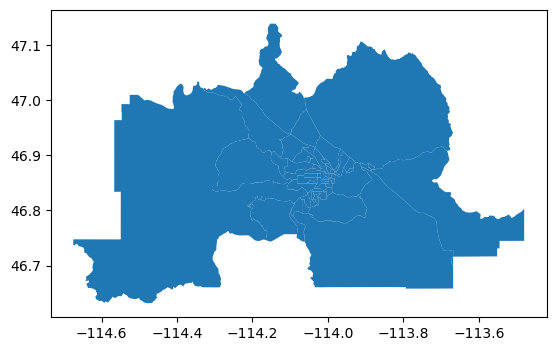

In [9]:
df.plot()

## Solution 7.1

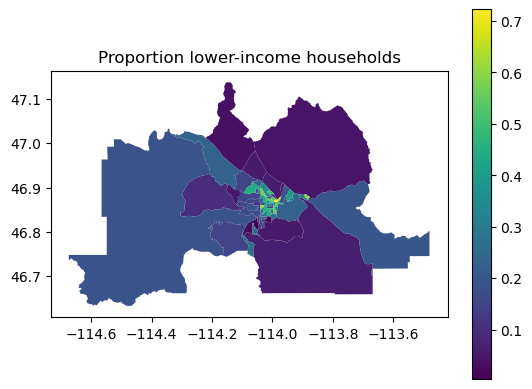

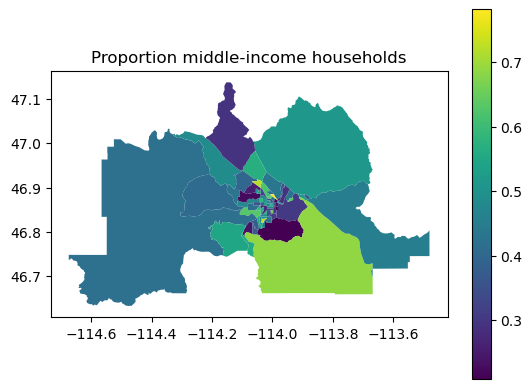

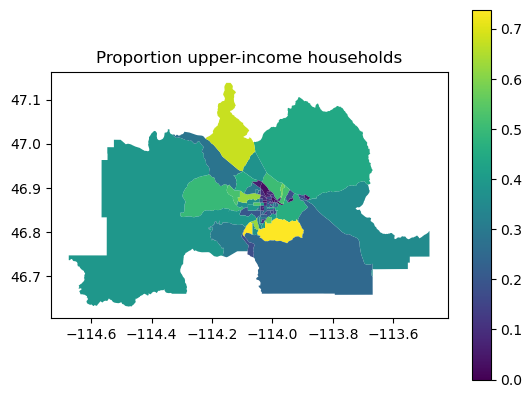

In [10]:
# total households (denominator)
total = df["B19001e1"]

# get proportion per census tract but avoid divide by zero error
df["prop_lower"]  = np.where(total > 0, df["lower_hholds"]  / total, np.nan)
df["prop_middle"] = np.where(total > 0, df["middle_hholds"] / total, np.nan)
df["prop_upper"]  = np.where(total > 0, df["upper_hholds"]  / total, np.nan)

# plot resulting maps
ax = df.plot("prop_lower", legend=True)
ax.set_title("Proportion lower-income households");
ax = df.plot("prop_middle", legend=True)
ax.set_title("Proportion middle-income households");
ax = df.plot("prop_upper", legend=True)
ax.set_title("Proportion upper-income households");

---

## Problem 7.2: Read in LST data

Let's read in our LST data from ECOSTRESS. This is a single-band image, but contains some zero values. We'll convert these to `np.nan` for display and analysis purposes. **Read this dataset in, convert it to `np.float32`, and convert any 0 values to `np.nan`. Plot the resulting raster.**

In [11]:
from matplotlib import pyplot

ds = rio.open('data/ECO_L2_LSTE.002_LST_doy2023236125736_aid0001.tif')

## Solution 7.2

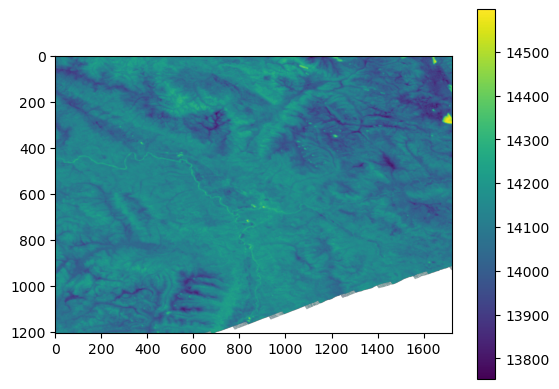

In [12]:
lst = ds.read(1).astype(np.float32) #convvert to float
lst[lst == 0] = np.nan #convert 0s to nans
# plot resulting raster
pyplot.imshow(lst)
pyplot.colorbar()
pyplot.show()

---

## Interlude: Rasterize the census blocks and align them to the LST data

Now that we have our raster and vector data situated, we want to merge them somehow. In QGIS or ArcGIS, we might use the "zonal statistics" tools, but those tools can be limiting in terms of the functions available. Therefore, it's sometime useful to do these types of operations in Python. **Here, we'll first convert our vector data to a raster, and then use array operations to get the summary statistics that we want.**

`rasterio.features` has a very helpful function, `rasterize()`, that does most of this for us. We do, however, need to provide it with a list of geometries from our vector dataset, along with the values that we want in our raster that correspond to each geometry. [See the documentation for help on how to use this function](https://rasterio.readthedocs.io/en/stable/api/rasterio.features.html#rasterio.features.rasterize). `rasterize()` expects these data in a list of tuples, e.g. `[(POLYGON(...), 12.7), (POLYGON(...), 13.2)...]`. Recall that `geopandas` stores the geometry of each row in the `geometry` column.

**We'll use the following Python function to rasterize our Census blocks so they align with the gridded LST dataset.**

In [13]:
from rasterio import features

def rasterize_and_align(raster, vector, field):
    if field == "GEOID":
        vector[field] = vector[field].astype(np.int64)
    else:
        vector[field] = vector[field].astype(np.float32)
    out_transform = raster.transform
    out_shape = raster.shape
    geoms = vector[["geometry", field]].values.tolist()
    if field == "GEOID": 
        # Use 64-bit integer for the GEOID field
        rasterized_data = features.rasterize(
            geoms, out_shape = out_shape, transform = out_transform, 
            dtype = np.int64)
    else:
        # Otherwise, use 32-bit floating point for data columns
        rasterized_data = features.rasterize(
            geoms, out_shape = out_shape, transform = out_transform, 
            dtype = np.float32)
    return rasterized_data

---

## Problem 7.3: Rasterize the GEOID and the proportion of people in each income bracket

Now, we want to use this function. **Using `rasterize_and_align()`, rasterize the `prop_*` fields you computed in 7.1, along with the `GEOID` fields.**

1. Flatten the resulting arrays (i.e., collapse the rows and columns into a single dimension, so that each row corresponds to a single pixel) using `array.flatten()`, and store the resulting data in some appreopriate data structure (e.g. `pandas DataFrame`, `dict`, `np.ndarray`).
2. Flatten and store your LST data in the same data structure (e.g., by creating a new column in the `pandas` `DataFrame`).
3. Rescale LST by using the equation $Celsius = DN * 0.02 - 273.15$, where $DN$ is the pixel value. This equation will convert ECOSTRESS LST to degrees Celsius. You should end up with numbers fairly close to the recorded air temperature (around 10-11 degrees Celsius).
4. Remove any data where the `GEOID` is equal to 0. This is the polygon corresponding to areas of nodata in the LST raster, which we don't want.
5. Print the number of observations in this dataset using either `shape` or `len`.

Since the LST data is aligned with all of your rasterized data, we will now be able to numerically analyze the relationships between the income level of the census blocks and LST. You should have exactly 831,897 observations for each variable (LST, proportion lower, proportion middle, proportion upper, GEOID).

## Solution 7.3

In [14]:
#1) rasterize LST grid
geoid_r = rasterize_and_align(ds, df, "GEOID")
lower_r = rasterize_and_align(ds, df, "prop_lower")
middle_r = rasterize_and_align(ds, df, "prop_middle")
upper_r = rasterize_and_align(ds, df, "prop_upper")

#2)make each row represent 1 pixel
pix = pd.DataFrame({
    "GEOID": geoid_r.flatten(),
    "prop_lower": lower_r.flatten(),
    "prop_middle": middle_r.flatten(),
    "prop_upper": upper_r.flatten(),
    "LST_DN": lst.flatten()
})

#3) convert LST to c degress
pix["LST_C"] = pix["LST_DN"] * 0.02 - 273.15

#4) remove polygons with no data
pix = pix[pix["GEOID"] != 0]

#5) print the number of observations
print(pix.shape)

(831897, 6)


---

## Problem 7.4: Analyze the relationship between income levels and LST

Finally, at long last, let's look at the relationship between LST and income levels. To do this, we'll need to **get the mean LST for each `GEOID`, along with the proportion of households for each `GEOID`.** Depending on what data structure you used in the previous problem, you may be able to do this in one line, or you may need to write a `for` loop.

**Make three scatterplots with the proportion of households within each income bracket on the x-axes, and average census block LST on the y-axis.**

## Solution 7.4

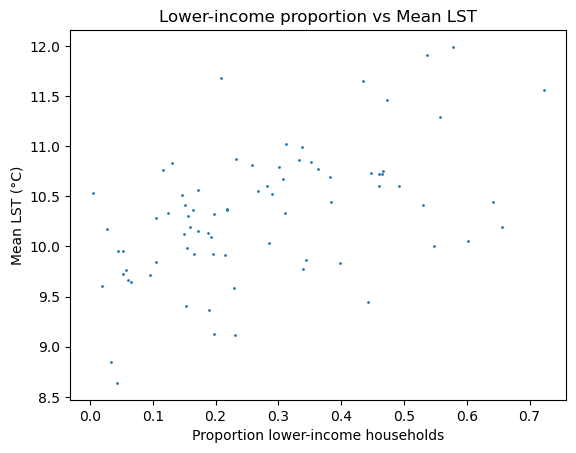

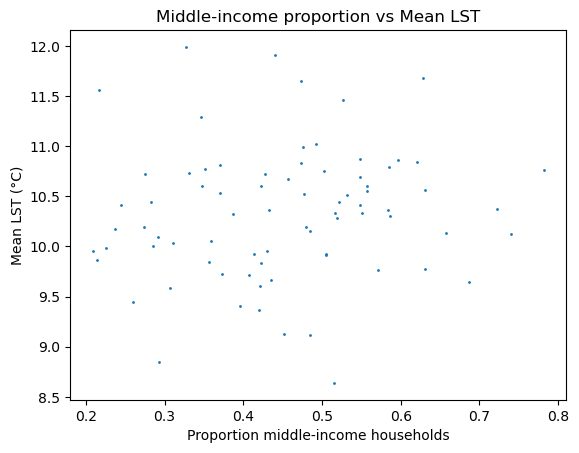

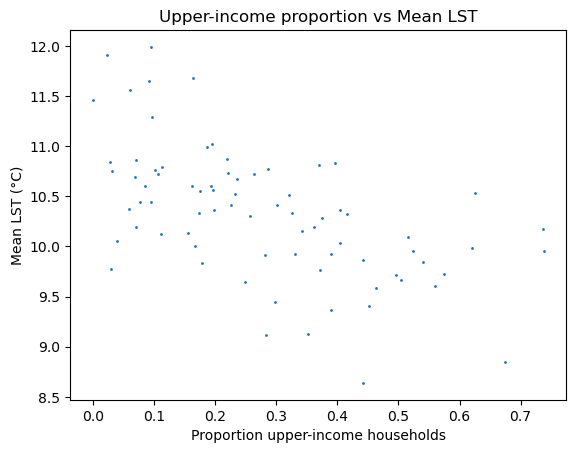

In [15]:
# get avg LST per GEOID and proportions per GEOID
by_geoid = pix.groupby("GEOID")[["LST_C", "prop_lower", "prop_middle", "prop_upper"]].mean()

# Plot lower vs LST
pyplot.scatter(by_geoid["prop_lower"], by_geoid["LST_C"], s=1)
pyplot.xlabel("Proportion lower-income households")
pyplot.ylabel("Mean LST (°C)")
pyplot.title("Lower-income proportion vs Mean LST")
pyplot.show()

#PLKot middle vs LST
pyplot.scatter(by_geoid["prop_middle"], by_geoid["LST_C"], s=1)
pyplot.xlabel("Proportion middle-income households")
pyplot.ylabel("Mean LST (°C)")
pyplot.title("Middle-income proportion vs Mean LST")
pyplot.show()

# Plot upper vs LST
pyplot.scatter(by_geoid["prop_upper"], by_geoid["LST_C"], s=1)
pyplot.xlabel("Proportion upper-income households")
pyplot.ylabel("Mean LST (°C)")
pyplot.title("Upper-income proportion vs Mean LST")
pyplot.show()